In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
%matplotlib qt
#%matplotlib ipympl



In [55]:
import os
# use os.listdir()  

directory = r'C:\Users\slaar\Desktop\project\HippocampalMRISlices\01'
dicom_path = os.listdir(directory)[4]
ds = pydicom.dcmread(os.path.join(directory, dicom_path))  # read dicom file
'''for index in range(len(os.scandir(directory))):  # loop through each entry in the directory
    entry = os.scandir(directory)[index]

for entry in os.scandir(directory):  # loop through each entry in the directory
    if '551459698506200377412175303061706085291' in str(entry): 
        ds = pydicom.dcmread(entry.path)  # read dicom file
        image_data = ds.pixel_array # EXTRACTS THE PIXE DATA FROM THE DICOM FILE
        #print(image_data[0x7FE0, 0x0010].value)
        plt.imshow(image_data, cmap='gray') # print pixel data of dicom file
        plt.axis('off')
        plt.show()'''
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 184
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.246.352.221.46302418903211096267121676894464665267
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.246.352.70.2.1.160.3
(0002,0013) Implementation Version Name         SH: 'DCIE 2.2'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'OTHER']
(0008,0012) Instance Creation Date              DA: '20220622'
(0008,0013) Instance Creation Time              TM: '115002'
(0008,0016) SOP Class UID                       UI: MR Image Storage
(0008,0018) SOP Instance UID               

In [3]:
print(image_data[0].shape)  # print the shape of the image data

(256,)


In [4]:
import imageio
def get_vol_data(end_digits):  # define function to get data from dicom file
    vol_data = imageio.volread(r"C:\Users\slaar\Desktop\project\HippocampalMRISlices\01\MR.1.2.246.352.221.{}.dcm".format(str(end_digits)))  # read dicom file
    return vol_data  # return dicom data

def slices(number_of_slice, slice_type, end_digits):
    '''returns the information of the specified slice, to be plotted
    slice_type are defined as 'axial', 'coronal', and 'saggital' 
    number_of_slice defines the specific slice to be returned
    '''
    vol = get_vol_data(end_digits)
    if slice_type == 'axial':
        return vol[number_of_slice,:,:]
    elif slice_type == 'coronal':
        return vol[:,number_of_slice,:]
    elif slice_type == 'saggital':
        return vol[:,:,number_of_slice]
    else:
        raise ValueError("Please choose from 'axial', 'coronal', or 'saggital', and a slice number must be between 0 and 255")

axial_slice = slices(90, 'axial', 551459698506200377412175303061706085291)
saggital_slice = slices(90, 'saggital', 551459698506200377412175303061706085291)
coronal_slice = slices(90, 'coronal', 551459698506200377412175303061706085291)

Reading DICOM (examining files): 1/278 files (0.44/278 files (1.46/278 files (2.28/278 files (2.910/278 files (3.6%14/278 files (5.0%17/278 files (6.1%20/278 files (7.2%25/278 files (9.0%31/278 files (11.234/278 files (12.238/278 files (13.744/278 files (15.850/278 files (18.055/278 files (19.861/278 files (21.966/278 files (23.772/278 files (25.975/278 files (27.079/278 files (28.483/278 files (29.988/278 files (31.793/278 files (33.595/278 files (34.2101/278 files (36.3%106/278 files (38.1%111/278 files (39.9%113/278 files (40.6%117/278 files (42.1%121/278 files (43.5%127/278 files (45.7%134/278 files (48.2%141/278 files (50.7%148/278 files (53.2%155/278 files (55.8%162/278 files (58.3%166/278 files (59.7%171/278 files (61.5%178/278 files (64.0%183/278 files (65.8%188/278 files (67.6%192/278 files (69.1%198/278 files (71.2%203/278 files (73.0%208/278 files (74.8%213/278 files (76.6%218/278 files (78.4%224/278 files (80.6%229/278 files (82.4%233/278 files (83.8%237/278 files (85.3%242

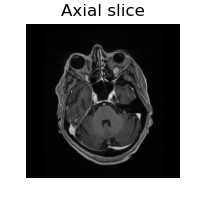

In [5]:
#####         AXIAL         #####
plt.close('all')
plt.figure(figsize=(2,2))
plt.imshow(axial_slice, cmap='gray')
plt.title('Axial slice')
plt.axis('off')
plt.show()

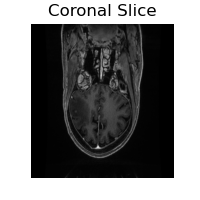

In [6]:
#####    CORONAL    #####
plt.figure(figsize=(2,2))
plt.imshow(coronal_slice, cmap='gray') # print pixel data of dicom file
plt.title('Coronal Slice')
plt.axis('off')
plt.show()

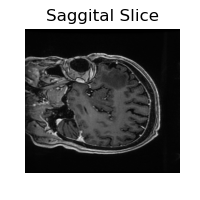

In [7]:
#####    SAGITTAL    #####
plt.figure(figsize=(2,2))
plt.imshow(saggital_slice.T, cmap='gray') # print pixel data of dicom file
plt.title('Saggital Slice')
plt.axis('off')
plt.show()

In [ ]:
def dictionary(directory):
    '''returns a dictionary
    key = order of th dicom file
    value = pixel data of the dicom file
    '''
    dicom_dict = {}
    dicom_order = []
    for entry in os.scandir(directory):
        if 'MR.1.2.246' in str(entry):
            order = int(str(entry)[30:37])
            ds = pydicom.dcmread(entry.path)
            dicom_dict[order] = ds.pixel_array
            dicom_order.append(order)
    return dicom_order, dicom_dict
directory = r'C:\Users\slaar\Desktop\project\HippocampalMRISlices\01'
dicom_dict = dictionary(directory)[1]
dicom_order = dictionary(directory)[0]

In [ ]:
def dictionary(directory):
    '''returns a dictionary
    key = order of the dicom file (0 to n)
    value = pixel data of the dicom file
    '''
    dicom_dict = {}
    dicom_order = []
    counter = 0
    for entry in os.scandir(directory):
        if 'MR.1.2.246' in str(entry):
            order = int(str(entry)[30:37])
            ds = pydicom.dcmread(entry.path)
            dicom_dict[counter] = ds.pixel_array
            dicom_order.append(counter)
        counter += 1
    return dicom_order, dicom_dict
directory = r'C:\Users\slaar\Desktop\project\HippocampalMRISlices\01'
dicom_dict = dictionary(directory)[1]
dicom_order = dictionary(directory)[0]

In [44]:
from matplotlib.widgets import Slider, Button
import IPython.display as display 

plt.close('all')
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.35)
ax_order = plt.axes([0.25, 0.1, 0.65, 0.03])
ax.imshow(dicom_dict[min(dicom_order)])

#create a slider for the dicom files
order_increments = []
for i in range(len(dicom_order)-1):
    increment = dicom_order[i+1]- dicom_order[i]
    order_increments.append(increment)

print(np.concatenate([np.linspace(0.1,5,100), [6,7,8,9]]))

order_slider = Slider(ax_order, 'Order', min(dicom_order), max(dicom_order), valinit=555011, valstep=order_increments, valfmt='%0.0f', color='lightblue')


def update(val):
    ord = order_slider.val
    ax.imshow(dicom_dict[ord])
    fig.canvas.draw_idle()

order_slider.on_changed(update)

ax_reset = fig.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(ax_reset, 'Reset', hovercolor='0.975')


def reset(event):
    sfreq.reset()
    samp.reset()
button.on_clicked(reset)

plt.show()
#ax.imshow(dicom_dict[val])


[0.1        0.14949495 0.1989899  0.24848485 0.2979798  0.34747475
 0.3969697  0.44646465 0.4959596  0.54545455 0.59494949 0.64444444
 0.69393939 0.74343434 0.79292929 0.84242424 0.89191919 0.94141414
 0.99090909 1.04040404 1.08989899 1.13939394 1.18888889 1.23838384
 1.28787879 1.33737374 1.38686869 1.43636364 1.48585859 1.53535354
 1.58484848 1.63434343 1.68383838 1.73333333 1.78282828 1.83232323
 1.88181818 1.93131313 1.98080808 2.03030303 2.07979798 2.12929293
 2.17878788 2.22828283 2.27777778 2.32727273 2.37676768 2.42626263
 2.47575758 2.52525253 2.57474747 2.62424242 2.67373737 2.72323232
 2.77272727 2.82222222 2.87171717 2.92121212 2.97070707 3.02020202
 3.06969697 3.11919192 3.16868687 3.21818182 3.26767677 3.31717172
 3.36666667 3.41616162 3.46565657 3.51515152 3.56464646 3.61414141
 3.66363636 3.71313131 3.76262626 3.81212121 3.86161616 3.91111111
 3.96060606 4.01010101 4.05959596 4.10909091 4.15858586 4.20808081
 4.25757576 4.30707071 4.35656566 4.40606061 4.45555556 4.5050

In [48]:
from matplotlib.widgets import Slider, Button
import IPython.display as display 

plt.close('all')
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.35)
ax_order = plt.axes([0.25, 0.1, 0.65, 0.03])
ax.imshow(dicom_dict[min(dicom_order)])

#create a slider for the dicom files
order_increments = []
for i in range(len(dicom_order)-1):
    increment = dicom_order[i+1]- dicom_order[i]
    order_increments.append(increment)

print(np.concatenate([np.linspace(0.1,5,100), [6,7,8,9]]))

order_slider = Slider(ax_order, 'Order', min(dicom_order), max(dicom_order), valinit=0, valstep=1, color='lightblue')


def update(val):
    ord = order_slider.val
    ax.imshow(dicom_dict[ord])
    fig.canvas.draw_idle()

order_slider.on_changed(update)

ax_reset = fig.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(ax_reset, 'Reset', hovercolor='0.975')


def reset(event):
    order_slider.reset()
button.on_clicked(reset)

plt.show()
#ax.imshow(dicom_dict[val])


[0.1        0.14949495 0.1989899  0.24848485 0.2979798  0.34747475
 0.3969697  0.44646465 0.4959596  0.54545455 0.59494949 0.64444444
 0.69393939 0.74343434 0.79292929 0.84242424 0.89191919 0.94141414
 0.99090909 1.04040404 1.08989899 1.13939394 1.18888889 1.23838384
 1.28787879 1.33737374 1.38686869 1.43636364 1.48585859 1.53535354
 1.58484848 1.63434343 1.68383838 1.73333333 1.78282828 1.83232323
 1.88181818 1.93131313 1.98080808 2.03030303 2.07979798 2.12929293
 2.17878788 2.22828283 2.27777778 2.32727273 2.37676768 2.42626263
 2.47575758 2.52525253 2.57474747 2.62424242 2.67373737 2.72323232
 2.77272727 2.82222222 2.87171717 2.92121212 2.97070707 3.02020202
 3.06969697 3.11919192 3.16868687 3.21818182 3.26767677 3.31717172
 3.36666667 3.41616162 3.46565657 3.51515152 3.56464646 3.61414141
 3.66363636 3.71313131 3.76262626 3.81212121 3.86161616 3.91111111
 3.96060606 4.01010101 4.05959596 4.10909091 4.15858586 4.20808081
 4.25757576 4.30707071 4.35656566 4.40606061 4.45555556 4.5050

## Rough work from here on

In [45]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import Button, Slider

t = np.arange(0.0, 1.0, 0.001)
a0 = 5
f0 = 3
s = a0 * np.sin(2 * np.pi * f0 * t)

fig, ax = plt.subplots()
fig.subplots_adjust(bottom=0.25)
l, = ax.plot(t, s, lw=2)

ax_freq = fig.add_axes((0.25, 0.1, 0.65, 0.03))
ax_amp = fig.add_axes((0.25, 0.15, 0.65, 0.03))

# define the values to use for snapping
allowed_amplitudes = np.concatenate([np.linspace(.1, 5, 100), [6, 7, 8, 9]])

# create the sliders
samp = Slider(
    ax_amp, "Amp", 0.1, 9.0,
    valinit=a0, valstep=allowed_amplitudes,
    color="green"
)

sfreq = Slider(
    ax_freq, "Freq", 0, 10*np.pi,
    valinit=2*np.pi, valstep=np.pi,
    initcolor='none'  # Remove the line marking the valinit position.
)


def update(val):
    amp = samp.val
    freq = sfreq.val
    l.set_ydata(amp*np.sin(2*np.pi*freq*t))
    fig.canvas.draw_idle()


sfreq.on_changed(update)
samp.on_changed(update)

ax_reset = fig.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(ax_reset, 'Reset', hovercolor='0.975')


def reset(event):
    sfreq.reset()
    samp.reset()
button.on_clicked(reset)


plt.show()

In [12]:
ds = pydicom.dcmread(r"C:\Users\slaar\Desktop\project\HippocampalMRISlices\01\MR.1.2.246.352.221.544551308083722857517320840700343887803.dcm")
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 186
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.246.352.221.544551308083722857517320840700343887803
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.246.352.70.2.1.160.3
(0002,0013) Implementation Version Name         SH: 'DCIE 2.2'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'OTHER']
(0008,0012) Instance Creation Date              DA: '20220622'
(0008,0013) Instance Creation Time              TM: '115005'
(0008,0016) SOP Class UID                       UI: MR Image Storage
(0008,0018) SOP Instance UID              

In [16]:
directory = r'C:\Users\slaar\Desktop\project\HippocampalMRISlices\01'  # set directory path
for entry in os.scandir(directory):
    if 'MR.1.2.246' in str(entry):
        order = str(entry)[30:37]
        ds = pydicom.dcmread(entry.path)
        
        print(order)
        

4614300
4621063
4624507
4629701
4630241
4634098
4636278
4637836
4643900
4644463
4648155
4656901
4661029
4662021
4671648
4672577
4673931
4674466
4675441
4676688
4678794
4681014
4681972
4683937
4687944
4688584
4689504
4698109
4706126
4709206
4711849
4714178
4714528
4724765
4736596
4748792
4749106
4758348
4759463
4767735
4770600
4773202
4776563
4781849
4787957
4789786
4792053
4801973
4813162
4815192
4820472
4826953
4829807
4833941
4837104
4840514
4853383
4860867
4869255
4870012
4882420
4889983
4890092
4891437
4896547
4897248
4902261
4915159
4920277
4922778
4922782
4926522
4928585
4934427
4935919
4937304
4942550
4946608
4946628
4947622
4948977
4953772
4960425
4960854
4961303
4963809
4964129
4964953
4969338
4974027
4990642
4992686
4993593
5001725
5004510
5005357
5012400
5016751
5020841
5031701
5037527
5042256
5046163
5046802
5047132
5050689
5052640
5067561
5070928
5071120
5071958
5073654
5074956
5077609
5084616
5091356
5097286
5099136
5107726
5115485
5122866
5130577
5131058
5135547
5140450


In [11]:
from matplotlib.widgets import Slider
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)
ax_slider = plt.axes([0.25, 0.1, 0.65, 0.03])
slider = Slider()

directory = r'C:\Users\slaar\Desktop\project\HippocampalMRISlices\01'  # set directory path
def all_slices (directory):
    '''returns the data o'''
    for entry in os.scandir(directory):  # loop through each entry in the directory
        if '551459698506200377412175303061706085291' in str(entry): 


def update(val):
    slice_number = int(slider.val)
    axial_slice = slices(slice_number, 'axial', 551459698506200377412175303061706085291)
    ax.imshow(axial_slice, cmap='gray')
    fig.canvas.draw_idle()

for entry in os.scandir(directory):  # loop through each entry in the directory




IndentationError: expected an indented block after 'if' statement on line 11 (3586112312.py, line 14)